In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

y_test      = np.load('y_test.npy',      allow_pickle=True)
y_pred_svm  = np.load('y_pred_svm.npy',  allow_pickle=True)
y_pred_bert = np.load('y_pred_bert.npy', allow_pickle=True)

print("Loaded! Total samples:", len(y_test))
print("Unique labels:", np.unique(y_test))

Loaded! Total samples: 2060
Unique labels: [0 1 2 3]


In [2]:
label_map = {0: 'depression', 1: 'anxiety', 2: 'PTSD', 3: 'normal'}

y_test_named      = np.array([label_map[i] for i in y_test])
y_pred_svm_named  = np.array([label_map[i] for i in y_pred_svm])
y_pred_bert_named = np.array([label_map[i] for i in y_pred_bert])

print("Sample named labels:", y_test_named[:5])

Sample named labels: ['anxiety' 'normal' 'anxiety' 'anxiety' 'PTSD']


In [3]:
classes = ['depression', 'anxiety', 'PTSD', 'normal']

print("===== SVM RESULTS =====")
print(classification_report(y_test_named, y_pred_svm_named, target_names=classes))

print("===== BERT RESULTS =====")
print(classification_report(y_test_named, y_pred_bert_named, target_names=classes))

===== SVM RESULTS =====
              precision    recall  f1-score   support

  depression       0.83      0.88      0.85       515
     anxiety       0.85      0.81      0.83       515
        PTSD       0.83      0.87      0.85       515
      normal       0.78      0.73      0.75       515

    accuracy                           0.82      2060
   macro avg       0.82      0.82      0.82      2060
weighted avg       0.82      0.82      0.82      2060

===== BERT RESULTS =====
              precision    recall  f1-score   support

  depression       0.92      0.86      0.89       515
     anxiety       0.80      0.89      0.84       515
        PTSD       0.90      0.87      0.88       515
      normal       0.82      0.82      0.82       515

    accuracy                           0.86      2060
   macro avg       0.86      0.86      0.86      2060
weighted avg       0.86      0.86      0.86      2060



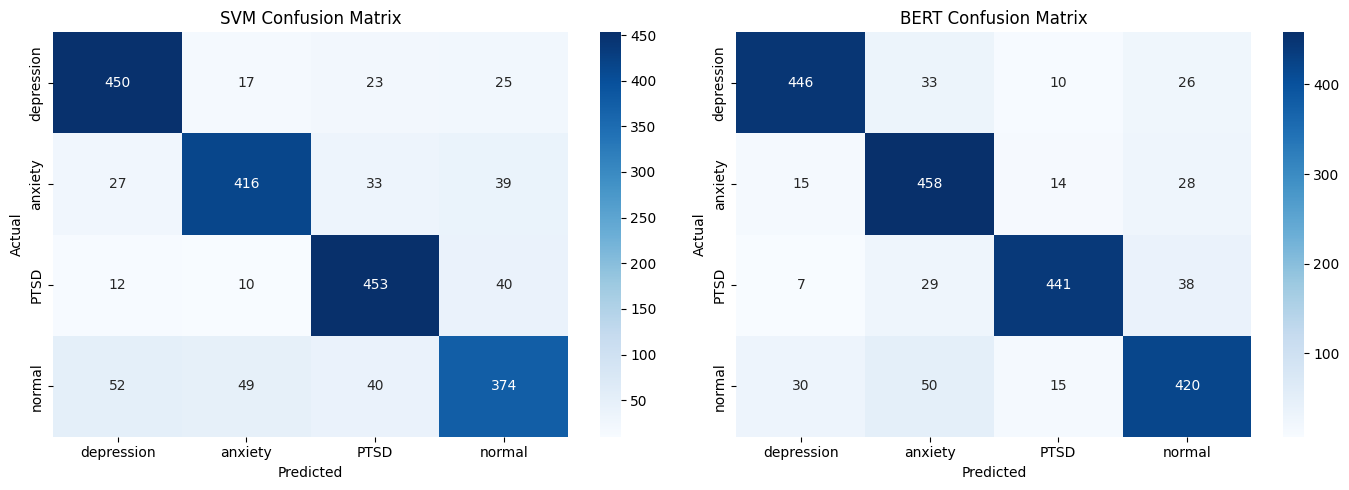

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                             [y_pred_svm_named, y_pred_bert_named],
                             ['SVM', 'BERT']):
    cm = confusion_matrix(y_test_named, preds, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=classes, yticklabels=classes,
                ax=ax, cmap='Blues')
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

In [5]:
summary = pd.DataFrame({
    'Model':       ['SVM', 'BERT'],
    'Accuracy':    [accuracy_score(y_test, y_pred_svm),
                    accuracy_score(y_test, y_pred_bert)],
    'Macro F1':    [f1_score(y_test, y_pred_svm,  average='macro'),
                    f1_score(y_test, y_pred_bert, average='macro')],
    'Weighted F1': [f1_score(y_test, y_pred_svm,  average='weighted'),
                    f1_score(y_test, y_pred_bert, average='weighted')]
})

summary.to_csv('evaluation_summary.csv', index=False)
print(summary)

  Model  Accuracy  Macro F1  Weighted F1
0   SVM  0.821845  0.820816     0.820816
1  BERT  0.856796  0.857285     0.857285
